# Learning to Implement Flow-Matching

In [1]:
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import rdkit.Chem as Chem
import torch
import torch.distributions as td
from torch.distributions.mixture_same_family import MixtureSameFamily
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
from tqdm import tqdm
from typing import Tuple
from wand.image import Image as WImage

import sys
sys.path.append("/home/alzub/projects/ggdl_self_learn/code/")
from plot_utils import set_plot_style
from gnn_.datasets_ import ProcessedInMemoryDataset, MUTAGMoleculeDataset, HIVMoleculeDataset
from gnn_.architectures import GNNDenoiserFiLMed, GNNDenoiserCrossAttended
from data_proc.mol_preproc import (
    TU_MUTAG_CONFIG, create_processor_list, batch_to_mols, fix_nitro_charges)
from generative.conditioning import MLPTimeDependent, UNetTimeClassDependent
from generative.base_dists import GaussianBase, MarginalGraphBase
from generative.flow_matching import (
    GaussianProbabilityPath, LinearGaussianSchedule, CatFlowInterpolant,
    ODESampler, ShortcutODESampler, CatFlowODESampler,
    ShortcutCatFlowODESampler,
    FlowMatchingModel, ShortCutFM, CatFlow, ShortcutCatFlow
)
from generative.discrete_flow_matching import (
    LinearDiscreteNoiser, LinearDiscreteRateMatrix, CTMCSampler, DeFoG
)
from solver_.ode_solvers import explicit_euler_fixed

/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_scatter/_scatter_cuda.so: undefined symbol: _ZN2at23SavedTensorDefaultHooks11set_tracingEb
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_sparse/_spmm_cuda.so: undefined symbol: _ZN2at23SavedTensorDefaultHooks11set_tracingEb
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [2]:
set_plot_style()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_DIR = Path("/home/alzub/projects/ggdl_self_learn")
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = DATA_DIR / "models/flow_matching"
SAMPLE_DIR = DATA_DIR / "samples/flow_matching"

plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128
plt.ioff()

FM_NAME_MAP = {
    "gaussot": "Gaussian Linear/OT",
    "gausssqrt": "Gaussian Sqrt. Variance"
}

## 0. Prerequisites

### 0.1 Toy Distributions

In [3]:
class TwoGaussians:
    def __init__(self):
        """
        A simple class to define an uneven mixture of two Gaussians.
        """

        mixture = td.Categorical(torch.tensor([1/5, 4/5]))
        components = td.Independent(td.Normal(
            torch.Tensor([
                [0.75, 0.75],
                [0.25, 0.25]
            ]),
            torch.Tensor([
                [0.1, 0.1],
                [0.1, 0.1]
            ])
        ), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = (0, 1)
        self.ylim = (0, 1)

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution

class ExtendedUniform(td.Uniform):
    def __init__(self, low, high, validate_args=None, outside_value=-float('inf')):
        """
        A uniform distribution that returns a constant value for values outside the support
        """
        super(ExtendedUniform, self).__init__(low, high, validate_args)
        self.outside_value = outside_value

    def log_prob(self, value):
        # Check if the value is within the support
        in_support = (value >= self.low) & (value <= self.high)
        safe_value = torch.where(in_support, value, self.low)
        log_prob = super().log_prob(safe_value)
        
        # Set log_prob to self.outside_value for values outside the support
        log_prob = torch.where(in_support, log_prob, torch.full_like(log_prob, self.outside_value))
        return log_prob
    
    @td.constraints.dependent_property(is_discrete=False, event_dim=0)
    def support(self):
        return td.constraints.real

class Chequerboard:
    def __init__(self, grid_size=3, bounds=[0.0, 1.0]):
        """
        A simple class to define the Chequerboard distribution.
        """

        square_size = (bounds[1] - bounds[0]) / grid_size

        weights = []
        low_list = []
        high_list = []
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 0:
                    low_x = bounds[0] + i * square_size
                    high_x = low_x + square_size
                    low_y = bounds[0] + j * square_size
                    high_y = low_y + square_size
                    
                    low_list.append([low_x, low_y])
                    high_list.append([high_x, high_y])
                    weights.append(1.0)

        mixture = td.Categorical(torch.tensor(weights))
        #components = td.Independent(td.uniform.Uniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        components = td.Independent(ExtendedUniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = bounds
        self.ylim = bounds

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution

### 0.2 MNIST Dataset and U-Net

In [3]:
batch_size = 256

mnist_train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=True, download=True,
        transform=transforms.Compose([transforms.ToTensor()])
    ),
    batch_size=batch_size, shuffle=True
)
mnist_test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=False, download=True,
        transform=transforms.Compose([transforms.ToTensor()])
    ),
    batch_size=batch_size*4, shuffle=True
)

In [4]:
def dequantize(x: torch.Tensor) -> torch.Tensor:
    x = x + torch.rand(x.shape, device=x.device)/255
    return (x-0.5)*2.0

### 0.3 TU MUTAG Data

In [5]:
mutag_raw = TUDataset(root=PROJECT_DIR / "data", name='MUTAG')
mutag_dataset = MUTAGMoleculeDataset(
    mutag_raw, DATA_DIR / "MUTAG_MOL", size_increase=1.4, force_reload=True)
mutag_loader = DataLoader(mutag_dataset, batch_size=50)

Processing...
processing MUTAG: 100%|██████████| 188/188 [00:00<00:00, 513.23it/s]
Done!


In [24]:
EDGE_LIST_STR = list(TU_MUTAG_CONFIG["edge_dict"].keys())
EDGE_LIST_RDK = list(TU_MUTAG_CONFIG["edge_dict"].values())
KEK_EDGE_DICT = {
    n: b for n, b in TU_MUTAG_CONFIG["edge_dict"].items() if n != "aromatic"}
KEK_EDGE_LIST_STR = list(KEK_EDGE_DICT.keys())
KEK_EDGE_LIST_RDK = list(KEK_EDGE_DICT.values())

In [25]:
trafos = create_processor_list(
    TU_MUTAG_CONFIG["node_list"], EDGE_LIST_STR, EDGE_LIST_RDK,
    TU_MUTAG_CONFIG["aromatic_idx"], max_n_atoms=TU_MUTAG_CONFIG["max_n_atoms"]
)

dataset = TUDataset(root=PROJECT_DIR / "data", name='MUTAG').to(DEVICE)
proc_dataset = ProcessedInMemoryDataset(dataset, trafos).to(DEVICE)

data_loader = DataLoader(proc_dataset, batch_size=50)

### 0.4 HIV Data

In [3]:

# Set this back to False after regenerating corrected processed files once.
REPROCESS_HIV = True
hiv_dataset = HIVMoleculeDataset(
    DATA_DIR / "HIV", "HIV.csv", size_increase=1.4,
    force_reload=REPROCESS_HIV
)
hiv_loader = DataLoader(hiv_dataset, batch_size=256)


Processing...
parsing molecules:  85%|████████▌ | 34998/41127 [00:22<00:04, 1407.67it/s][20:10:51] WARNING: not removing hydrogen atom without neighbors
[20:10:51] WARNING: not removing hydrogen atom without neighbors
formatting graph features: 100%|██████████| 41127/41127 [00:43<00:00, 936.59it/s] 
Done!


# 1. Flow-Matching Architectures

### 1.1 For Toy Data

In [7]:
def make_toy_fm(
    x_sample_size: int, hidden_size: int, embedding_size: int,
    n_blocks: int=4, act_fun: nn.Module=nn.GELU,
    schedule: nn.Module=LinearGaussianSchedule, device: str="cpu"
) -> nn.Module:
    base_dist = GaussianBase((x_sample_size,))
    model = FlowMatchingModel(
        MLPTimeDependent(
            100, embedding_size,
            x_sample_size, x_sample_size, [hidden_size]*n_blocks,
            continuous=True,
            mlp_act_funs=[act_fun]*n_blocks + [None],
            film_act_fun=act_fun
        ),
        GaussianProbabilityPath(schedule()),
        base_dist,
        ODESampler(base_dist, device=device),
        device=device
    ).to(device)

    return model

def make_toy_scfm(
    x_sample_size: int, hidden_size: int, embedding_size: int,
    n_blocks: int=4, act_fun: nn.Module=nn.GELU, device: str="cpu"
) -> nn.Module:
    base_dist = GaussianBase((x_sample_size,))
    model = ShortCutFM(
        MLPTimeDependent(
            100, embedding_size,
            x_sample_size, x_sample_size, [hidden_size]*n_blocks,
            continuous=True, n_vars=2,
            mlp_act_funs=[act_fun]*n_blocks + [None],
            film_act_fun=act_fun
        ),
        GaussianProbabilityPath(LinearGaussianSchedule()),
        base_dist,
        ShortcutODESampler(base_dist, device=device),
        device=device
    ).to(device)

    return model

### 1.2 For MNIST

In [8]:
def make_mnist_fm_model(
    img_size: Tuple[int, int, int], time_embedding_size: int,
    class_embedding_size: int, n_classes: int=10,
    unet_act_fun: nn.Module=nn.LogSigmoid, film_act_fun: nn.Module=nn.GELU,
    schedule: nn.Module=LinearGaussianSchedule, device: str="cpu"
) -> nn.Module:
    base_dist = GaussianBase(img_size)
    model = FlowMatchingModel(
        UNetTimeClassDependent(
            # FiLM pars
            100, time_embedding_size, class_embedding_size, n_classes,
            # CNN pars
            img_size[1], img_size[0], [32, 64, 128, 256, 256],
            # convolution
            [3, 3, 3, 3, 3], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1],
            # pooling
            [2, 2, 2, 2, 0], [2, 2, 2, 2, 1], [0, 0, 1, 0, 0],
            # transpose convolution
            [3, 3, 3, 3, 3], [2, 2, 2, 2, 1], [1, 1, 1, 1, 1], [1, 0, 1, 1, 0],
            continuous=True,
            unet_act_fun=unet_act_fun, film_act_fun=film_act_fun
        ),
        GaussianProbabilityPath(schedule()),
        base_dist,
        ODESampler(base_dist, device=device),
        device=device
    ).to(device)

    return model

def make_mnist_scfm_model(
    img_size: Tuple[int, int, int], time_embedding_size: int,
    class_embedding_size: int, n_classes: int=10,
    unet_act_fun: nn.Module=nn.LogSigmoid, film_act_fun: nn.Module=nn.GELU,
    device: str="cpu"
) -> nn.Module:
    base_dist = GaussianBase(img_size)
    model = ShortCutFM(
        UNetTimeClassDependent(
            # FiLM pars
            100, time_embedding_size, class_embedding_size, n_classes,
            # CNN pars
            img_size[1], img_size[0], [32, 64, 128, 256, 256],
            # convolution
            [3, 3, 3, 3, 3], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1],
            # pooling
            [2, 2, 2, 2, 0], [2, 2, 2, 2, 1], [0, 0, 1, 0, 0],
            # transpose convolution
            [3, 3, 3, 3, 3], [2, 2, 2, 2, 1], [1, 1, 1, 1, 1], [1, 0, 1, 1, 0],
            continuous=True, n_vars=2,
            unet_act_fun=unet_act_fun, film_act_fun=film_act_fun
        ),
        GaussianProbabilityPath(LinearGaussianSchedule()),
        base_dist,
        ShortcutODESampler(base_dist, device=device),
        device=device
    ).to(device)

    return model

### 1.3 For MUTAG

# 2. Flow-Matching on Toy Data

## 2.1 Two-Gaussians

In [9]:
# Generate the data
n_data = 10000000
toy = TwoGaussians()
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

In [ ]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

epochs = 3
lr = 1e-3

n_timesteps = 100
embedding_size = 24
hidden_size = 64

for i, (fm_type, make_fun) in enumerate(zip(
    ["gaussot", "gaussot_shortcut"], (
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=LinearGaussianSchedule, device=d),
        lambda x_s, h, e, d: make_toy_scfm(x_s, h, e, device=d)
    )
)):
    model = make_fun(x_sample_size, hidden_size, embedding_size, DEVICE)
    n_model_pars = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of {fm_type} Parameters: {n_model_pars}.")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    loss_fun = nn.MSELoss()
    model.train()

    total_steps = len(train_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)
            vf_hat, vf = model(x)
            loss = loss_fun(vf_hat, vf)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy1_{fm_type}_{epochs}_n_epochs.pt"
    )

Number of gaussot Parameters: 25702.


Training:   0%|          | 0/5000 [28:53<?, ?it/s, epoch=5/5, loss=⠀      0.1667]


Number of gaussot_shortcut Parameters: 31582.


Training: 100%|█████████▉| 2999/3000 [02:46<00:00, 17.10it/s, epoch=3/3, loss=⠀      0.2138]

Training: 100%|██████████| 3000/3000 [02:56<00:00, 17.10it/s, epoch=3/3, loss=⠀      0.2138]

In [40]:
progress_bar.reset()

Training:   0%|          | 0/3000 [00:00<?, ?it/s, epoch=3/3, loss=⠀      0.2138]           

/home/alzub/tmp/ipykernel_2547551/908293808.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


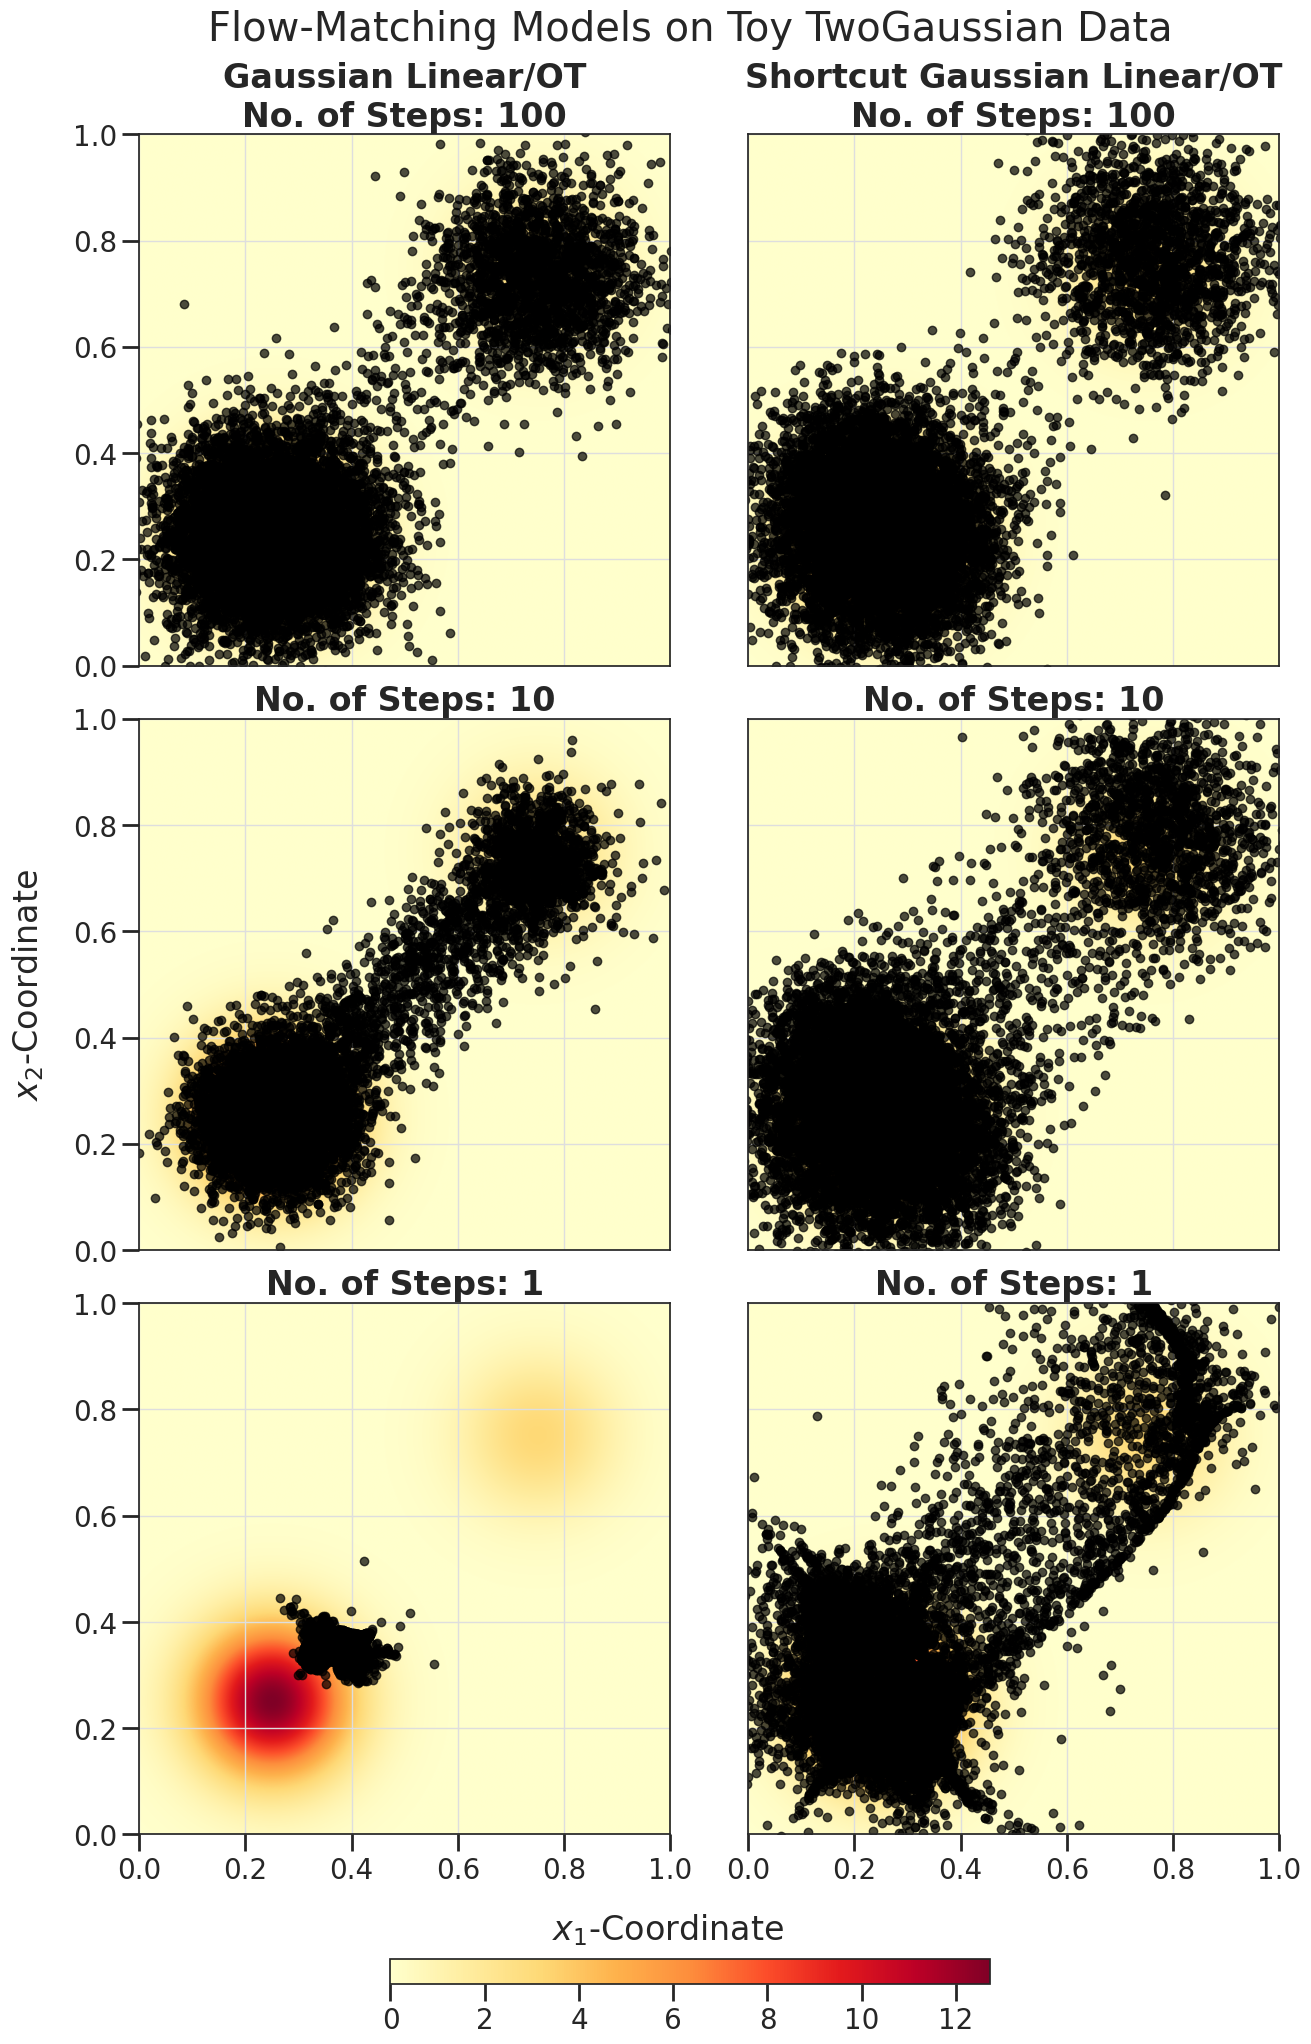

In [62]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 25))
gs_plot = fig.add_gridspec(3, 2, bottom=0.2)
gs_cbar = fig.add_gridspec(1, 1, top=0.15, bottom=0.14, left=0.3, right=0.7)

epochs = 3
embedding_size = 24
hidden_size = 64
for i, (fm_type, make_fun) in enumerate(zip(
    ["gaussot", "gaussot_shortcut"], (
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=LinearGaussianSchedule, device=d),
        lambda x_s, h, e, d: make_toy_scfm(x_s, h, e, device=d)
    )
)):
    model = make_fun(x_sample_size, hidden_size, embedding_size, DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy1_{fm_type}_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))

    for j, n_ode_steps in enumerate((100, 10, 1)):
        with torch.inference_mode():
            model.eval()
            samples = model.sample((10000,), n_steps=n_ode_steps)
            samples = samples.detach().cpu().numpy()

        ax = fig.add_subplot(gs_plot[j, i])
        im = ax.imshow(
            prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
            origin='lower', cmap='YlOrRd'
        )

        ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

        ax.set_xlim(toy.xlim)
        ax.set_ylim(toy.ylim)
        ax.set_aspect("equal")
            
        if i > 0:
            ax.tick_params(left=False, labelleft=False)
            ax.set_ylabel("")
        else:
            if j == 1:
                ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
            else:
                ax.set_ylabel("")
        
        if j < 2:
            ax.tick_params(bottom=False, labelbottom=False)
            ax.set_xlabel("")
        else:
            if i == 1:
                ax.set_xlabel("$x_1$-Coordinate", labelpad=20, x=-0.15)
            else:
                ax.set_xlabel("")
        
        if j == 0:
            if "_" in fm_type:
                fm_name, _ = fm_type.split("_")
                title = "Shortcut " + FM_NAME_MAP[fm_name] + "\n"
            else:
                title = FM_NAME_MAP[fm_type] + "\n"
        else:
            title = ""
        title += f"No. of Steps: {n_ode_steps}"
        ax.set_title(title, weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle(
    "Flow-Matching Models on Toy TwoGaussian Data", y=0.93)

plt.subplots_adjust(hspace=0.1, wspace=0.1)
plt.show()

## 2.2 Chequerboard

In [68]:
# Generate the data
n_data = 10000000
toy = Chequerboard()
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

In [ ]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

epochs = 3
lr = 1e-3

n_timesteps = 100
embedding_size = 24
hidden_size = 64

for i, (fm_type, make_fun) in enumerate(zip(
    ["gaussot", "gaussot_shortcut"], (
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=LinearGaussianSchedule, device=d),
        lambda x_s, h, e, d: make_toy_scfm(x_s, h, e, device=d)
    )
)):
    model = make_fun(x_sample_size, hidden_size, embedding_size, DEVICE)
    n_model_pars = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of {fm_type} Parameters: {n_model_pars}.")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    loss_fun = nn.MSELoss()
    model.train()

    total_steps = len(train_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)
            vf_hat, vf = model(x)
            loss = loss_fun(vf_hat, vf)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy2_{fm_type}_{epochs}_n_epochs.pt"
    )

Number of gaussot Parameters: 25702.


Training:   0%|          | 0/3000 [08:00<?, ?it/s, epoch=3/3, loss=⠀      0.8348]


Number of gaussot_shortcut Parameters: 31582.


Training: 100%|██████████| 3000/3000 [02:41<00:00, 18.43it/s, epoch=3/3, loss=⠀      0.3423]

Training: 100%|██████████| 3000/3000 [02:54<00:00, 18.43it/s, epoch=3/3, loss=⠀      0.3423]

In [70]:
progress_bar.reset()

Training:   0%|          | 0/3000 [00:00<?, ?it/s, epoch=3/3, loss=⠀      0.3423]           

/home/alzub/tmp/ipykernel_2547551/3912167546.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


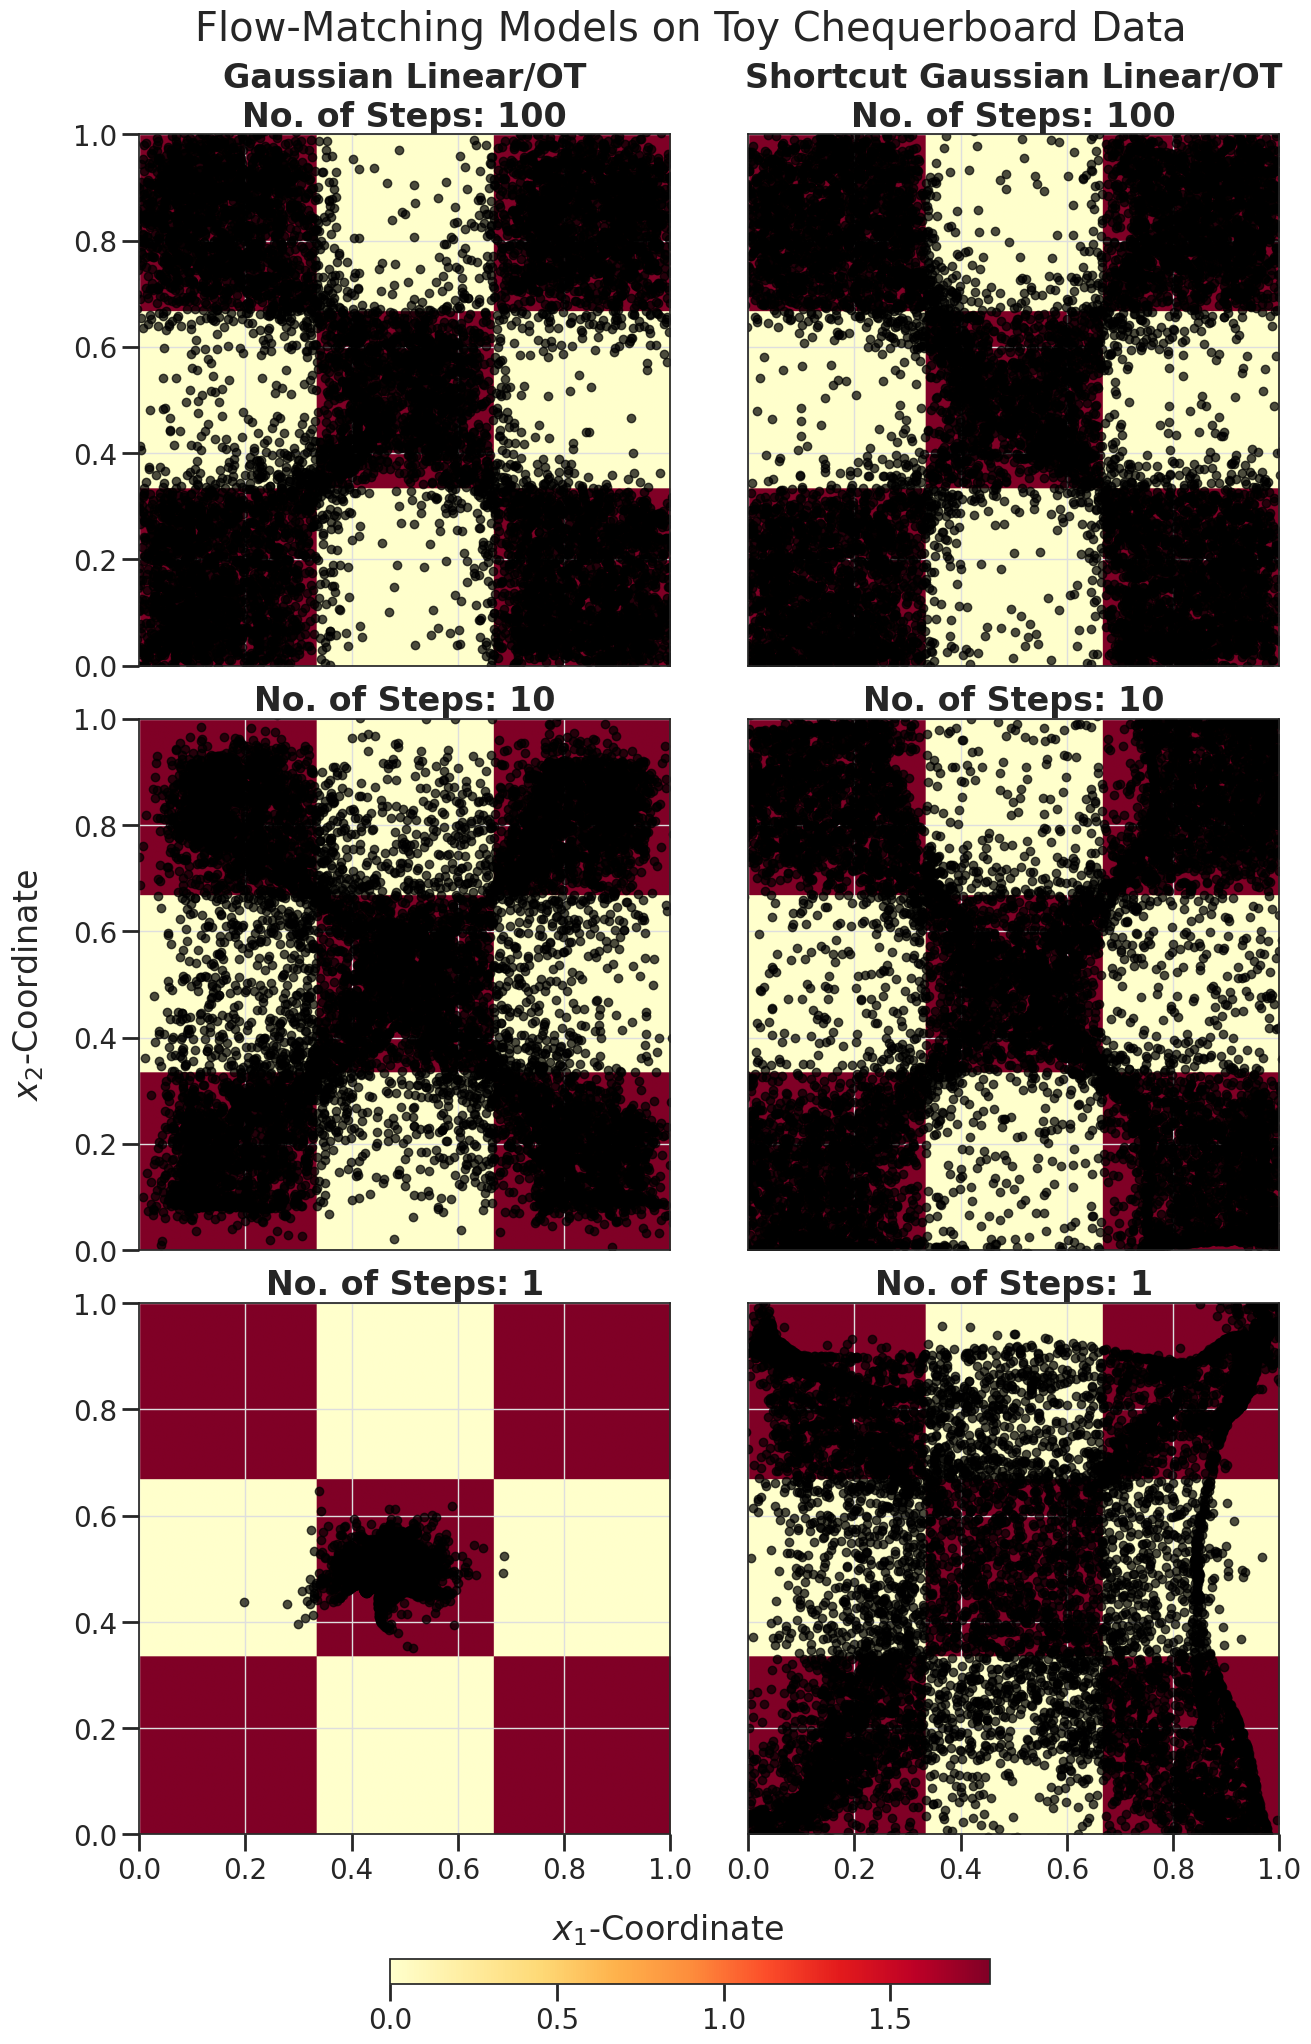

In [73]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 25))
gs_plot = fig.add_gridspec(3, 2, bottom=0.2)
gs_cbar = fig.add_gridspec(1, 1, top=0.15, bottom=0.14, left=0.3, right=0.7)

epochs = 3
embedding_size = 24
hidden_size = 64
for i, (fm_type, make_fun) in enumerate(zip(
    ["gaussot", "gaussot_shortcut"], (
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=LinearGaussianSchedule, device=d),
        lambda x_s, h, e, d: make_toy_scfm(x_s, h, e, device=d)
    )
)):
    model = make_fun(x_sample_size, hidden_size, embedding_size, DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy2_{fm_type}_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))

    for j, n_ode_steps in enumerate((100, 10, 1)):
        with torch.inference_mode():
            model.eval()
            samples = model.sample((10000,), n_steps=n_ode_steps)
            samples = samples.detach().cpu().numpy()

        ax = fig.add_subplot(gs_plot[j, i])
        im = ax.imshow(
            prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
            origin='lower', cmap='YlOrRd'
        )

        ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

        ax.set_xlim(toy.xlim)
        ax.set_ylim(toy.ylim)
        ax.set_aspect("equal")
            
        if i > 0:
            ax.tick_params(left=False, labelleft=False)
            ax.set_ylabel("")
        else:
            if j == 1:
                ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
            else:
                ax.set_ylabel("")
        
        if j < 2:
            ax.tick_params(bottom=False, labelbottom=False)
            ax.set_xlabel("")
        else:
            if i == 1:
                ax.set_xlabel("$x_1$-Coordinate", labelpad=20, x=-0.15)
            else:
                ax.set_xlabel("")
        
        if j == 0:
            if "_" in fm_type:
                fm_name, _ = fm_type.split("_")
                title = "Shortcut " + FM_NAME_MAP[fm_name] + "\n"
            else:
                title = FM_NAME_MAP[fm_type] + "\n"
        else:
            title = ""
        title += f"No. of Steps: {n_ode_steps}"
        ax.set_title(title, weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle(
    "Flow-Matching Models on Toy Chequerboard Data", y=0.93)

plt.subplots_adjust(hspace=0.1, wspace=0.1)
plt.show()

# 3. Flow-Matching on Easy, Real Data

## 3.1 MNIST

In [30]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 50
lr = 1e-3

time_embedding_size = 128
class_embedding_size = 128
n_classes = 10
for i, (fm_type, make_fun) in enumerate(zip(
    ["gaussot", "gaussot_shortcut"], (
        lambda x_s, t_s, c_s, d: make_mnist_fm_model(x_s, t_s, c_s, device=d),
        lambda x_s, t_s, c_s, d: make_mnist_scfm_model(x_s, t_s, c_s, device=d)
    )
)):
    if fm_type == "gaussot":
        continue
    model = make_fun(
        (n_channels, height, width), time_embedding_size, class_embedding_size,
        DEVICE
    ).to(DEVICE)
    n_model_pars = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of {fm_type} Parameters: {n_model_pars}.")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    loss_fun = nn.MSELoss()
    model.train()

    total_steps = len(mnist_train_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")
    for epoch in range(epochs):
        for x, y in mnist_train_loader:
            optimizer.zero_grad()

            x, y = x.to(DEVICE), y.to(DEVICE)
            x = dequantize(x)
            vf_hat, vf = model(x, y=y)
            
            loss = loss_fun(vf_hat, vf)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

    torch.save(
        model.state_dict(),
        MODEL_DIR
            / f"mnist_{fm_type}_conditional_{epochs}_n_epochs.pt"
    )

Number of gaussot_shortcut Parameters: 3162531.


Training:   0%|          | 0/11750 [00:41<?, ?it/s, epoch=50/50, loss=⠀567756803686196225746403328.0000]


In [28]:
progress_bar.reset()

Training:   0%|          | 0/11750 [00:00<?, ?it/s, epoch=50/50, loss=⠀567756803686196225746403328.0000]            

In [33]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 50

time_embedding_size = 128
class_embedding_size = 128
gamma_hidden = 1024
n_classes = 10
for i, (fm_type, make_fun) in enumerate(zip(
    ["gaussot", "gaussot_shortcut"], (
        lambda x_s, t_s, c_s, d: make_mnist_fm_model(x_s, t_s, c_s, device=d),
        lambda x_s, t_s, c_s, d: make_mnist_scfm_model(x_s, t_s, c_s, device=d)
    )
)):
    model = make_fun(
        (n_channels, height, width), time_embedding_size, class_embedding_size,
        DEVICE
    ).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"mnist_{fm_type}_conditional_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))

    # Generate samples
    for j, n_ode_steps in enumerate((100, 10, 1)):
        model.eval()
        with torch.no_grad():
            y = torch.arange(
                10, device=DEVICE, dtype=torch.long).expand((10, 10)).T.flatten()
            samples = (
                model
                    .sample((100,), y=y, show_path=False, n_steps=n_ode_steps)
                    .detach()
                    .cpu()
            )
            samples = samples/2 + 0.5
            save_image(
                samples,
                SAMPLE_DIR / f"mnist_{fm_type}_conditional_{epochs}_n_epochs_{n_ode_steps}_n_steps.png",
                normalize=False, nrow=10
            )

/home/alzub/tmp/ipykernel_2768022/1903301070.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


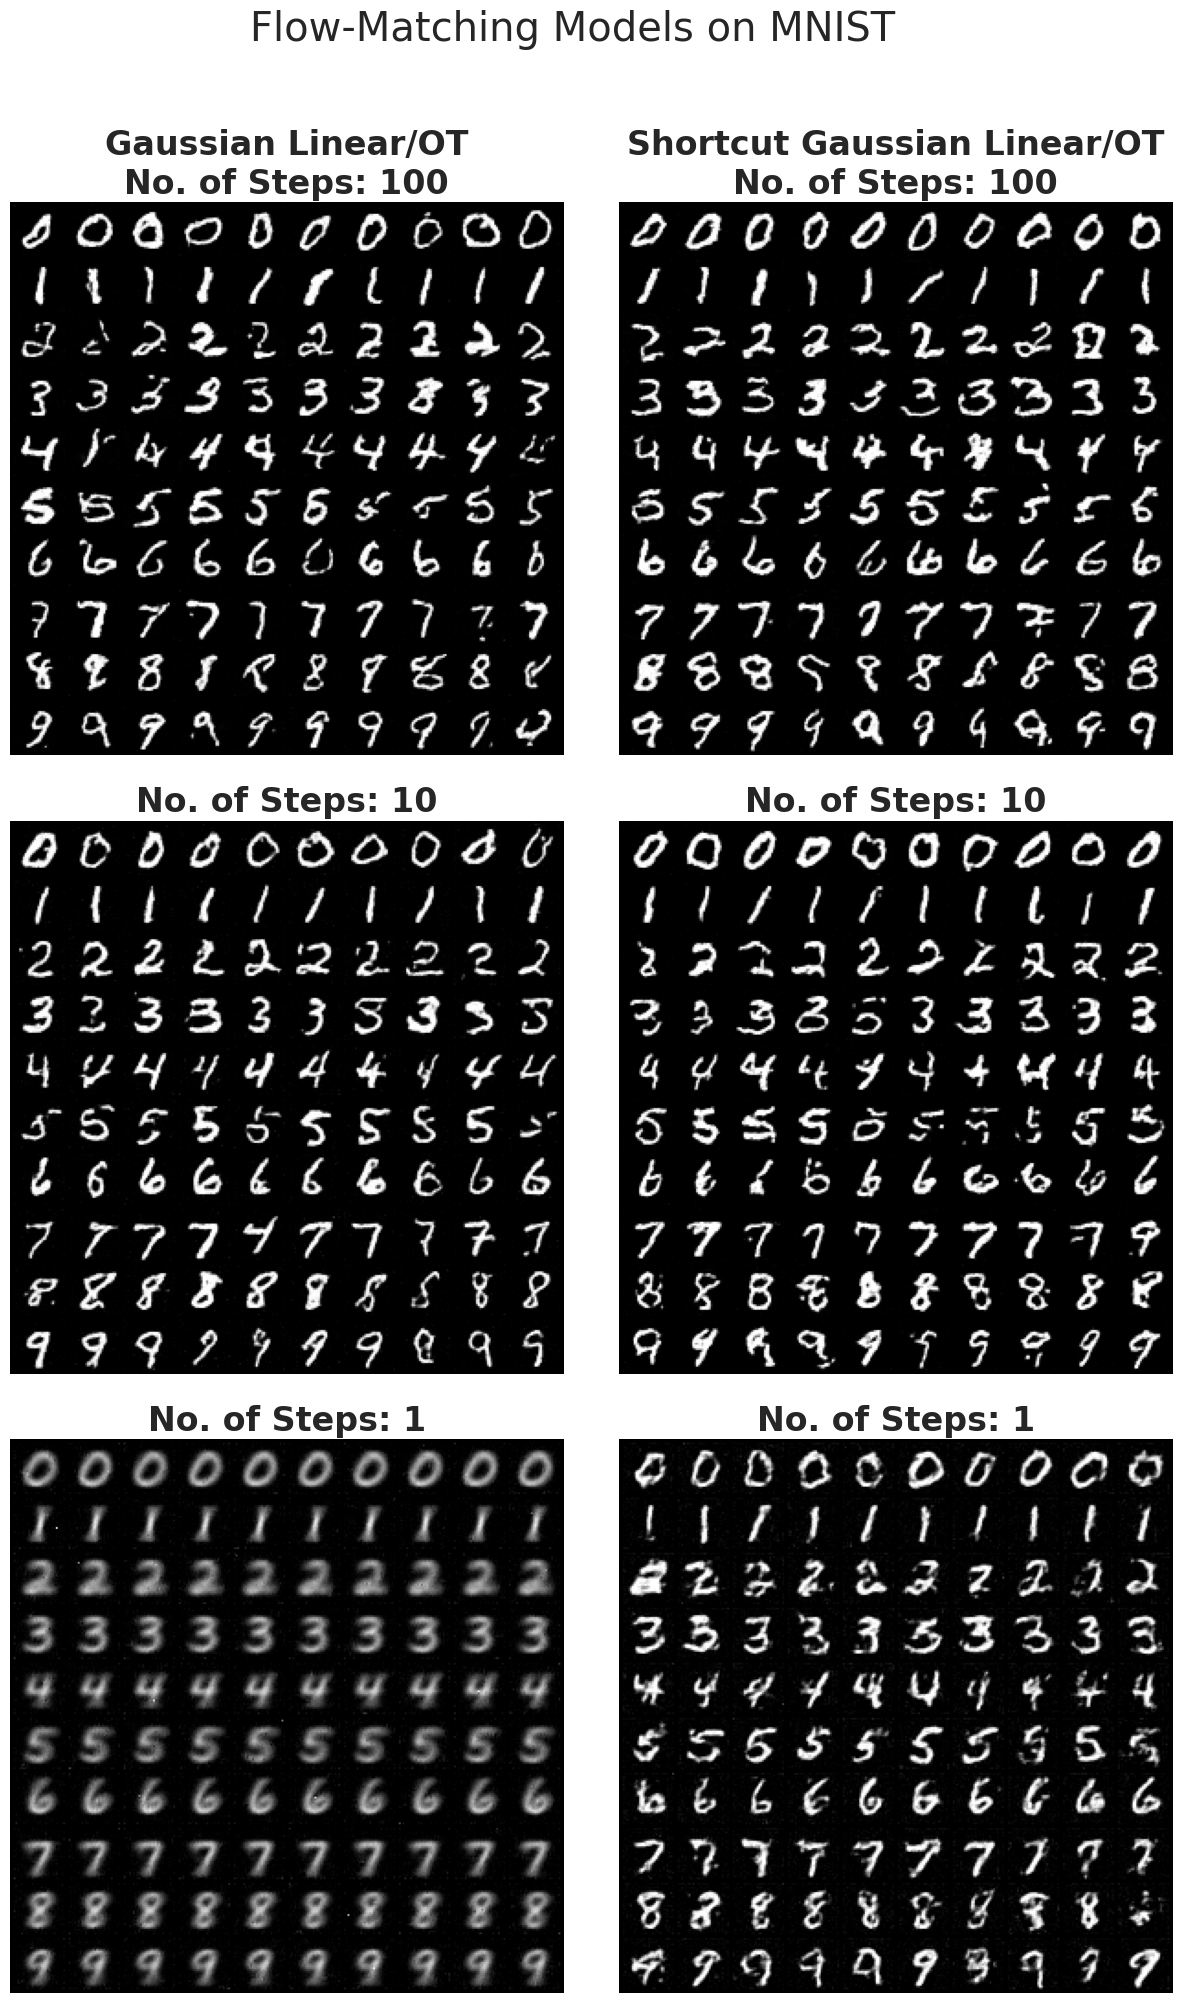

In [39]:
fig = plt.figure(figsize=(15, 25))
gs_plot = fig.add_gridspec(3, 2)

epochs = 50

for i, fm_type in enumerate(("gaussot", "gaussot_shortcut")):
    for j, n_ode_steps in enumerate((100, 10, 1)):
        ax = fig.add_subplot(gs_plot[j, i])
        img = WImage(
            filename=SAMPLE_DIR
                / f"mnist_{fm_type}_conditional_{epochs}_n_epochs_{n_ode_steps}_n_steps.png"
            )
        ax.imshow(img)
        ax.axis("off")
        
        if j == 0:
            if "_" in fm_type:
                fm_name, _ = fm_type.split("_")
                title = "Shortcut " + FM_NAME_MAP[fm_name] + "\n"
            else:
                title = FM_NAME_MAP[fm_type] + "\n"
        else:
            title = ""
        title += f"No. of Steps: {n_ode_steps}"
        ax.set_title(title, weight="bold")

fig.suptitle(
    "Flow-Matching Models on MNIST", y=0.93)

plt.subplots_adjust(hspace=-0.1, wspace=0.1)
plt.show()

# 4. Flow-Matching On Hard, Real Data

## 4.1 MUTAG Molecule Data

### 4.1.1 DeFoG

In [6]:

base_dist = MarginalGraphBase(mutag_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)
n_atom_tokens, n_bond_tokens = (
    mutag_dataset.n_atom_tokens, mutag_dataset.n_bond_tokens)
node_hidden_size, edge_hidden_size = 64, 64
embedding_dim = 8
n_classes = 2
n_update = 4
denoiser = GNNDenoiserCrossAttended(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    embedding_dim, n_layers=n_update, message_passing="gineconv",
    loader=mutag_loader, ca_heads=4,
    conditioning_args=[
        ("cont_sine_pe", {"embedding_dim": embedding_dim}),
        ("class", {"embedding_dim": embedding_dim, "n_classes": 10}),
        ("scalar_fourier", {"embedding_dim": embedding_dim}),
        ("scalar_fourier", {"embedding_dim": embedding_dim}),
        ("scalar_fourier", {"embedding_dim": embedding_dim})
    ]
).to(DEVICE)
sampler = CTMCSampler(
    base_dist, LinearDiscreteRateMatrix(
        base_dist, n_atom_tokens, n_bond_tokens).to(DEVICE), n_atom_tokens,
    n_bond_tokens, mutag_dataset.max_capacity, device=DEVICE,
    bond_types=mutag_dataset.bond_token_names,
)
model = DeFoG(
    base_dist, noiser, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    mutag_dataset.max_capacity
).to(DEVICE)

lambda_ = 4.0
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()
epochs = 300

total_steps = len(mutag_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for batch in mutag_loader:
        optimizer.zero_grad()

        edge_weights = torch.ones(batch.edge_attr.size(-1), dtype=torch.float)
        edge_weights[mutag_dataset.bond_token_names.index("triple")] = 0.45
        edge_weights[mutag_dataset.bond_token_names.index("no_bond")] = 0.8
        loss = model(
            batch.to(DEVICE), edge_loss_weight=lambda_,
            edge_weights=edge_weights,
        )

        loss.backward()
        optimizer.step()

        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

progress_bar.close()
torch.save(
    model.state_dict(),
    MODEL_DIR / f"mutag_defog_conditional_{epochs}_n_epochs.pt"
)


Training: 100%|██████████| 1200/1200 [01:49<00:00, 10.92it/s, epoch=300/300, loss=⠀      1.2856]


In [7]:
progress_bar.reset()

In [ ]:

base_dist = MarginalGraphBase(mutag_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)
n_atom_tokens, n_bond_tokens = (
    mutag_dataset.n_atom_tokens, mutag_dataset.n_bond_tokens)
node_hidden_size, edge_hidden_size = 64, 64
embedding_dim = 8
n_classes = 2
n_update = 4
denoiser = GNNDenoiserCrossAttended(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    embedding_dim, n_layers=n_update, message_passing="gineconv",
    loader=mutag_loader, ca_heads=4,
    conditioning_args=[
        ("cont_sine_pe", {"embedding_dim": embedding_dim}),
        ("class", {"embedding_dim": embedding_dim, "n_classes": 10}),
        ("scalar_fourier", {"embedding_dim": embedding_dim}),
        ("scalar_fourier", {"embedding_dim": embedding_dim}),
        ("scalar_fourier", {"embedding_dim": embedding_dim})
    ]
).to(DEVICE)
sampler = CTMCSampler(
    base_dist, LinearDiscreteRateMatrix(
        base_dist, n_atom_tokens, n_bond_tokens).to(DEVICE), n_atom_tokens,
    n_bond_tokens, mutag_dataset.max_capacity, device=DEVICE,
    bond_types=mutag_dataset.bond_token_names,
)
model = DeFoG(
    base_dist, noiser, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    mutag_dataset.max_capacity
).to(DEVICE)

epochs = 300
model.load_state_dict(torch.load(
    MODEL_DIR / f"mutag_defog_conditional_{epochs}_n_epochs.pt",
    map_location=torch.device(DEVICE)
))

with torch.inference_mode():
    model.eval()
    n_samples = 500
    n_steps = 100
    y = torch.cat((
        torch.ones((n_samples//2,), dtype=torch.long),
        torch.zeros((n_samples//2,), dtype=torch.long),
    )).to(DEVICE)

    target_n_atoms = 24
    target_n_heteroatoms = 5
    target_n_rings = 3
    sample_max_n_nodes = mutag_dataset.capacity_for_n_atoms(target_n_atoms)
    conditioning = mutag_dataset.sample_conditioning(
        target_n_atoms, target_n_heteroatoms, target_n_rings,
        repeat=n_samples, device=DEVICE,
    )

    batch = model.sample(
        (n_samples,), y=y, conditioning=conditioning, n_steps=n_steps,
        no_atom_bias=-2.3, bond_order_bias=(-1.0, -2.0, 0.0),
        exit_cap=0.6, temp_scales=(0.5, 1.0),
        max_n_nodes=sample_max_n_nodes,
    )


/home/alzub/tmp/ipykernel_1393272/236301096.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


In [22]:

sampled_mols = batch_to_mols(
    batch, mutag_dataset.atom_vocab, mutag_dataset.bond_vocab,
    sample_max_n_nodes,
)


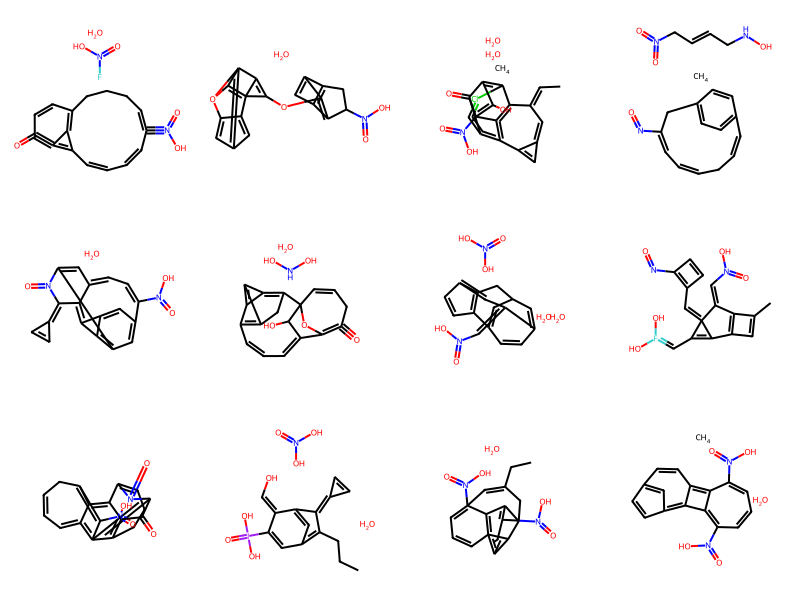

In [23]:
Chem.Draw.MolsToGridImage(
    np.random.choice(sampled_mols, 12, replace=False), molsPerRow=4
)

In [24]:
fully_connected = 0
valid = 0
valid_mols = []
fc_val = 0
fc_val_size = 0

for mol in sampled_mols:
    smiles = Chem.MolToSmiles(mol)
    if "." not in smiles:
        fully_connected += 1
    try:
        fix_nitro_charges(mol)
        valid += 1
    except:
        pass

    try:
        mol_val = fix_nitro_charges(mol)
        if "." not in smiles:
            fc_val_size += mol_val.GetNumAtoms(onlyExplicit=True)
            valid_mols.append(mol_val)
            fc_val += 1
    except:
        pass

fc_ratio = fully_connected / n_samples
valid_ratio = valid / n_samples
fc_val_ratio = fc_val / n_samples
fc_val_size = fc_val_size / fc_val

print(f"Ratio of fully connected graphs: {fc_ratio*100} %")
print(f"Ratio of chemically valid molecules: {valid_ratio*100} %")
print(f"Ratio of fully connected, valid molecules: {fc_val_ratio*100} % ")
print(f"Avg. Size fully connected, valid molecules: {fc_val_size} atoms")

[20:17:21] Explicit valence for atom # 3 N, 7, is greater than permitted
[20:17:21] Explicit valence for atom # 3 N, 7, is greater than permitted
[20:17:21] Explicit valence for atom # 9 N, 7, is greater than permitted
[20:17:21] Explicit valence for atom # 9 N, 7, is greater than permitted
[20:17:21] Explicit valence for atom # 12 O, 3, is greater than permitted
[20:17:21] Explicit valence for atom # 12 O, 3, is greater than permitted
[20:17:21] Explicit valence for atom # 8 N, 6, is greater than permitted
[20:17:21] Explicit valence for atom # 8 N, 6, is greater than permitted
[20:17:21] Explicit valence for atom # 4 C, 6, is greater than permitted
[20:17:21] Explicit valence for atom # 4 C, 6, is greater than permitted
[20:17:21] Explicit valence for atom # 3 C, 5, is greater than permitted
[20:17:21] Explicit valence for atom # 3 C, 5, is greater than permitted
[20:17:21] Explicit valence for atom # 3 C, 6, is greater than permitted
[20:17:21] Explicit valence for atom # 3 C, 6, is

Ratio of fully connected graphs: 13.200000000000001 %
Ratio of chemically valid molecules: 17.0 %
Ratio of fully connected, valid molecules: 1.2 % 
Avg. Size fully connected, valid molecules: 24.166666666666668 atoms


In [28]:
base_dist = MarginalGraphBase(mutag_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)
n_atom_tokens, n_bond_tokens = (
    len(mutag_dataset.atom_vocab)+1, len(mutag_dataset.bond_vocab)+1)
node_hidden_size, edge_hidden_size = 64, 64
embedding_dim = 8
n_classes = 2
n_update = 4
denoiser = GNNDenoiserCrossAttended(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    5*embedding_dim, n_layers=n_update, message_passing="gineconv",
    loader=mutag_loader, ca_heads=4,
    conditioning_args=[
        ("cont_sine_pe", {"embedding_dim": embedding_dim}),
        ("class", {"embedding_dim": embedding_dim, "n_classes": 10}),
        ("scalar_fourier", {"embedding_dim": embedding_dim}),
        ("scalar_fourier", {"embedding_dim": embedding_dim}),
        ("scalar_fourier", {"embedding_dim": embedding_dim})
    ]
).to(DEVICE)
sampler = CTMCSampler(
    base_dist, LinearDiscreteRateMatrix(
        base_dist, n_atom_tokens, n_bond_tokens).to(DEVICE), n_atom_tokens,
    n_bond_tokens, TU_MUTAG_CONFIG["max_n_atoms"], device=DEVICE
)
model = DeFoG(
    base_dist, noiser, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    TU_MUTAG_CONFIG["max_n_atoms"]
).to(DEVICE)

n_model_pars = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of Parameters: {n_model_pars}.")

Number of Parameters: 1334220.


**OLD**

In [26]:
base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)
n_atom_tokens, n_bond_tokens = 8, 4
node_hidden_size, edge_hidden_size = 96, 32
time_emb_size, class_emb_size = 32, 32
n_classes = 2
n_update = 4
denoiser = GNNDenoiserFiLMed(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    time_emb_size, class_emb_size, n_classes, n_update,
    message_passing="pna_conv", loader=data_loader
).to(DEVICE)
sampler = CTMCSampler(
    base_dist, LinearDiscreteRateMatrix(
        base_dist, n_atom_tokens, n_bond_tokens).to(DEVICE), n_atom_tokens,
    n_bond_tokens, TU_MUTAG_CONFIG["max_n_atoms"], device=DEVICE
)
model = DeFoG(
    base_dist, noiser, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    TU_MUTAG_CONFIG["max_n_atoms"]
).to(DEVICE)

In [27]:
n_model_pars = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of Parameters: {n_model_pars}.")

Number of Parameters: 1879692.


In [ ]:
base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)
n_atom_tokens, n_bond_tokens = 8, 4
node_hidden_size, edge_hidden_size = 96, 32
time_emb_size, class_emb_size = 32, 32
n_classes = 2
n_update = 4
denoiser = GNNDenoiser(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    time_emb_size, class_emb_size, n_classes, n_update,
    message_passing="pna_conv", loader=data_loader
).to(DEVICE)
sampler = CTMCSampler(
    base_dist, LinearDiscreteRateMatrix(
        base_dist, n_atom_tokens, n_bond_tokens).to(DEVICE), n_atom_tokens,
    n_bond_tokens, TU_MUTAG_CONFIG["max_n_atoms"], device=DEVICE
)
model = DeFoG(
    base_dist, noiser, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    TU_MUTAG_CONFIG["max_n_atoms"]
).to(DEVICE)

lambda_ = 4.0
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()
epochs = 1000

total_steps = len(data_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for batch in data_loader:
        optimizer.zero_grad()

        loss = model(
            batch, edge_loss_weight=lambda_,
            edge_weights=torch.tensor([1.0, 1.0, 0.45, 0.8])
        )

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()
    
    torch.save(
        model.state_dict(),
        MODEL_DIR
            / f"mutag_defog_conditional_{epochs}_n_epochs.pt"
    )

Training:   0%|          | 0/2000 [05:05<?, ?it/s, epoch=500/500, loss=⠀      0.8418]
/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)
/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)
Training: 100%|██████████| 4000/4000 [09:01<00:00, 12.57it/s, epoch=1000/1000, loss=⠀      1.0881]

Training: 100%|██████████| 4000/4000 [09:17<00:00, 12.57it/s, epoch=1000/1000, loss=⠀      1.0881]

In [ ]:
base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)
n_atom_tokens, n_bond_tokens = 8, 4
node_hidden_size, edge_hidden_size = 32, 48
time_emb_size, class_emb_size = 32, 64
n_classes = 2
n_update = 4
denoiser = GNNDenoiser(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    time_emb_size, class_emb_size, n_classes, n_update,
    message_passing="pna_conv", loader=data_loader
).to(DEVICE)
sampler = CTMCSampler(
    base_dist, LinearDiscreteRateMatrix(
        base_dist, n_atom_tokens, n_bond_tokens).to(DEVICE), n_atom_tokens,
    n_bond_tokens, TU_MUTAG_CONFIG["max_n_atoms"], device=DEVICE
)
model = DeFoG(
    base_dist, noiser, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    TU_MUTAG_CONFIG["max_n_atoms"]
).to(DEVICE)

lambda_ = 0.5
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
model.train()
epochs = 2000

total_steps = len(data_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for batch in data_loader:
        optimizer.zero_grad()

        loss = model(
            batch, edge_loss_weight=lambda_,
            node_weights=torch.Tensor([1, 1, 1, 1, 1, 1, 1, 0.4]),
            edge_weights=torch.tensor([1.0, 0.7, 0.1, 0.8])
        )

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()
    
    torch.save(
        model.state_dict(),
        MODEL_DIR
            / f"mutag_defog_conditional_{epochs}_n_epochs.pt"
    )

Training:   0%|          | 0/1200 [00:00<?, ?it/s]/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)
/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)
Training: 100%|██████████| 1200/1200 [02:40<00:00,  9.47it/s, epoch=300/300, loss=⠀      0.4632]

In [7]:
progress_bar.reset()

Training:   0%|          | 0/1200 [00:00<?, ?it/s, epoch=300/300, loss=⠀      0.4632]           

In [ ]:
base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)
n_atom_tokens, n_bond_tokens = 8, 4
node_hidden_size, edge_hidden_size = 32, 48
time_emb_size, class_emb_size = 32, 64
n_classes = 2
n_update = 4
denoiser = GNNDenoiser(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    time_emb_size, class_emb_size, n_classes, n_update,
    message_passing="pna_conv", loader=data_loader
).to(DEVICE)
sampler = CTMCSampler(
    base_dist, LinearDiscreteRateMatrix(
        base_dist, n_atom_tokens, n_bond_tokens).to(DEVICE), n_atom_tokens,
    n_bond_tokens, TU_MUTAG_CONFIG["max_n_atoms"], device=DEVICE
)
model = DeFoG(
    base_dist, noiser, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    TU_MUTAG_CONFIG["max_n_atoms"]
).to(DEVICE)

epochs = 2000
model.load_state_dict(torch.load(
    MODEL_DIR / f"mutag_defog_conditional_{epochs}_n_epochs.pt",
    map_location=torch.device(DEVICE)
))

with torch.inference_mode():
    model.eval()
    n_samples = 500
    n_steps = 100
    y = torch.cat((
        torch.ones((n_samples//2,), dtype=torch.long),
        torch.zeros((n_samples//2,), dtype=torch.long),
    ))

    batch = model.sample(
        (n_samples,), y=y, n_steps=n_steps, no_atom_bias=-2.3,
        bond_order_bias=(-1.0, -2.0, 0.0),
        exit_cap=0.6, temp_scales=(0.5, 1.0)
    )

/home/alzub/tmp/ipykernel_1160469/3916438910.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


In [9]:
sampled_mols = batch_to_mols(
    batch, TU_MUTAG_CONFIG["node_list"], KEK_EDGE_LIST_RDK,
    TU_MUTAG_CONFIG["max_n_atoms"]
)

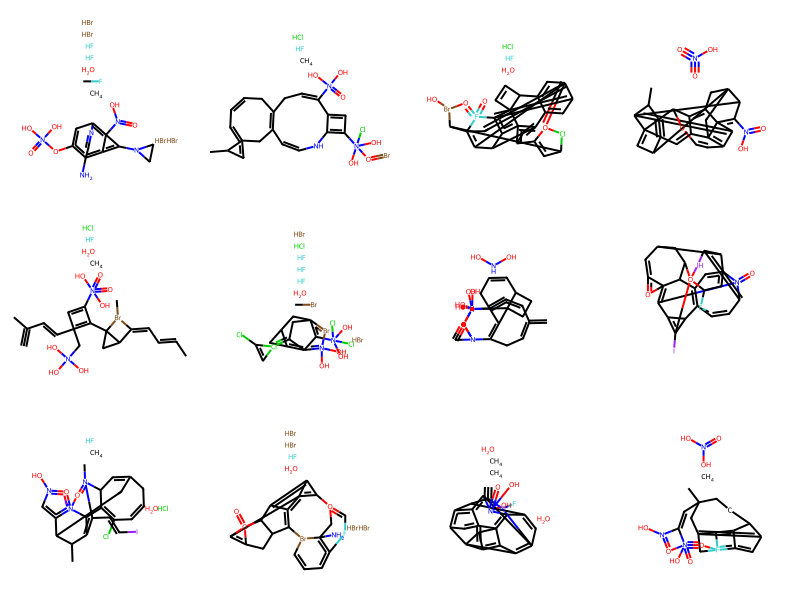

In [14]:
Chem.Draw.MolsToGridImage(
    np.random.choice(sampled_mols, 12, replace=False), molsPerRow=4
)

In [11]:
fully_connected = 0
valid = 0
valid_mols = []
fc_val = 0
fc_val_size = 0

for mol in sampled_mols:
    smiles = Chem.MolToSmiles(mol)
    if "." not in smiles:
        fully_connected += 1
    try:
        fix_nitro_charges(mol)
        valid += 1
    except:
        pass

    try:
        mol_val = fix_nitro_charges(mol)
        if "." not in smiles:
            fc_val_size += mol_val.GetNumAtoms(onlyExplicit=True)
            valid_mols.append(mol_val)
            fc_val += 1
    except:
        pass

fc_ratio = fully_connected / n_samples
valid_ratio = valid / n_samples
fc_val_ratio = fc_val / n_samples
fc_val_size = fc_val_size / fc_val

print(f"Ratio of fully connected graphs: {fc_ratio*100} %")
print(f"Ratio of chemically valid molecules: {valid_ratio*100} %")
print(f"Ratio of fully connected, valid molecules: {fc_val_ratio*100} % ")
print(f"Avg. Size fully connected, valid molecules: {fc_val_size} atoms")

[01:03:22] Explicit valence for atom # 1 Br, 2, is greater than permitted
[01:03:22] Explicit valence for atom # 1 Br, 2, is greater than permitted
[01:03:22] Explicit valence for atom # 17 N, 4, is greater than permitted
[01:03:22] Explicit valence for atom # 17 N, 4, is greater than permitted
[01:03:22] Explicit valence for atom # 2 C, 5, is greater than permitted
[01:03:22] Explicit valence for atom # 2 C, 5, is greater than permitted
[01:03:22] Explicit valence for atom # 2 C, 6, is greater than permitted
[01:03:22] Explicit valence for atom # 2 C, 6, is greater than permitted
[01:03:22] Explicit valence for atom # 4 N, 6, is greater than permitted
[01:03:22] Explicit valence for atom # 4 N, 6, is greater than permitted
[01:03:22] Explicit valence for atom # 0 O, 4, is greater than permitted
[01:03:22] Explicit valence for atom # 0 O, 4, is greater than permitted
[01:03:22] Explicit valence for atom # 11 C, 5, is greater than permitted
[01:03:22] Explicit valence for atom # 11 C, 5

ZeroDivisionError: division by zero

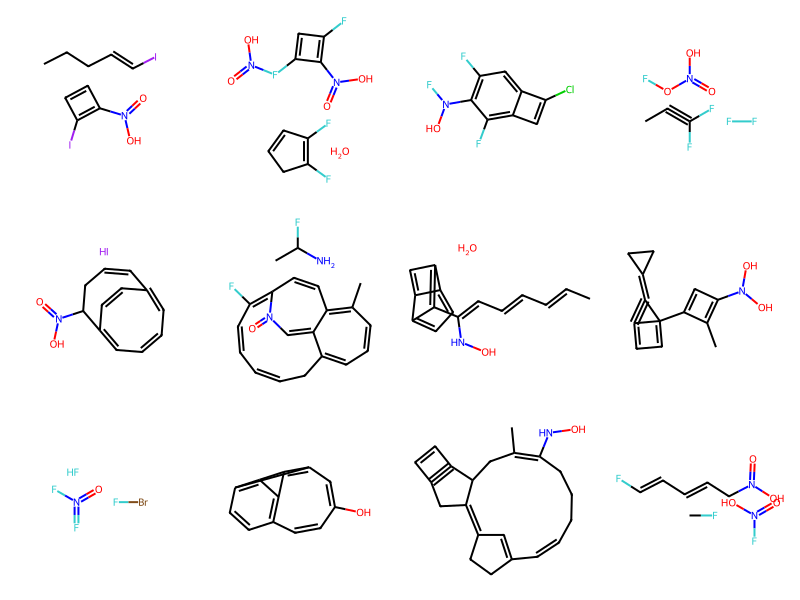

In [20]:
Chem.Draw.MolsToGridImage(
    np.random.choice(sampled_mols, 12, replace=False), molsPerRow=4
)

In [115]:
fully_connected = 0
valid = 0
valid_mols = []
fc_val = 0
fc_val_size = 0

for mol in sampled_mols:
    smiles = Chem.MolToSmiles(mol)
    if "." not in smiles:
        fully_connected += 1
    try:
        fix_nitro_charges(mol)
        valid += 1
    except:
        pass

    try:
        mol_val = fix_nitro_charges(mol)
        if "." not in smiles:
            fc_val_size += mol_val.GetNumAtoms(onlyExplicit=True)
            valid_mols.append(mol_val)
            fc_val += 1
    except:
        pass

fc_ratio = fully_connected / n_samples
valid_ratio = valid / n_samples
fc_val_ratio = fc_val / n_samples
fc_val_size = fc_val_size / fc_val

print(f"Ratio of fully connected graphs: {fc_ratio*100} %")
print(f"Ratio of chemically valid molecules: {valid_ratio*100} %")
print(f"Ratio of fully connected, valid molecules: {fc_val_ratio*100} % ")
print(f"Avg. Size fully connected, valid molecules: {fc_val_size} atoms")

Ratio of fully connected graphs: 42.0 %
Ratio of chemically valid molecules: 54.6 %
Ratio of fully connected, valid molecules: 21.2 % 
Avg. Size fully connected, valid molecules: 12.679245283018869 atoms


[11:25:15] Explicit valence for atom # 2 O, 5, is greater than permitted
[11:25:15] Explicit valence for atom # 2 O, 5, is greater than permitted
[11:25:15] Explicit valence for atom # 7 N, 4, is greater than permitted
[11:25:15] Explicit valence for atom # 7 N, 4, is greater than permitted
[11:25:15] Explicit valence for atom # 21 C, 5, is greater than permitted
[11:25:15] Explicit valence for atom # 21 C, 5, is greater than permitted
[11:25:15] Explicit valence for atom # 0 C, 5, is greater than permitted
[11:25:15] Explicit valence for atom # 0 C, 5, is greater than permitted
[11:25:15] Explicit valence for atom # 0 C, 5, is greater than permitted
[11:25:15] Explicit valence for atom # 0 C, 5, is greater than permitted
[11:25:15] Explicit valence for atom # 1 C, 5, is greater than permitted
[11:25:15] Explicit valence for atom # 1 C, 5, is greater than permitted
[11:25:15] Explicit valence for atom # 13 C, 5, is greater than permitted
[11:25:15] Explicit valence for atom # 13 C, 5, 

### 4.1.2 VFM / CatFlow

*Normal FM*

In [ ]:
base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
interpolator = CatFlowInterpolant(base_dist, TU_MUTAG_CONFIG["max_n_atoms"])
n_atom_tokens, n_bond_tokens = 8, 4
node_hidden_size, edge_hidden_size = 96, 96
time_emb_size, class_emb_size = 96, 96
n_classes = 2
n_update = 4
denoiser = GNNDenoiser(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    time_emb_size, class_emb_size, n_classes, n_update,
    message_passing="pna_conv", loader=data_loader, input_type="probs"
).to(DEVICE)
sampler = CatFlowODESampler(
    base_dist, n_atom_tokens, n_bond_tokens, TU_MUTAG_CONFIG["max_n_atoms"],
    device=DEVICE
)
model = CatFlow(
    base_dist, interpolator, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    TU_MUTAG_CONFIG["max_n_atoms"]
).to(DEVICE)

lambda_ = 2.0
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
model.train()
epochs = 3000

total_steps = len(data_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for batch in data_loader:
        optimizer.zero_grad()

        loss = model(
            batch, edge_loss_weight=lambda_,
            edge_weights=torch.tensor([1.0, 0.6, 0.25, 1.3])
        )

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()
    
    torch.save(
        model.state_dict(),
        MODEL_DIR
            / f"mutag_catflow_conditional_{epochs}_n_epochs.pt"
    )

Training:   0%|          | 0/12000 [00:00<?, ?it/s]/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)
/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)
Training: 100%|█████████▉| 11999/12000 [38:14<00:00,  9.64it/s, epoch=3000/3000, loss=⠀      0.0171] 

In [ ]:
progress_bar.reset()

Training:   0%|          | 0/4000 [00:00<?, ?it/s, epoch=1000/1000, loss=⠀      1.2104]           

*Shortcut*

In [23]:
base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
interpolator = CatFlowInterpolant(base_dist, TU_MUTAG_CONFIG["max_n_atoms"])
n_atom_tokens, n_bond_tokens = 8, 4
node_hidden_size, edge_hidden_size = 96, 64
time_emb_size, class_emb_size = 96, 96
n_classes = 2
n_update = 5
denoiser = GNNDenoiser(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    time_emb_size, class_emb_size, n_classes, n_update, n_vars=2,
    message_passing="pna_conv", loader=data_loader, input_type="probs"
).to(DEVICE)
sampler = ShortcutCatFlowODESampler(
    base_dist, n_atom_tokens, n_bond_tokens, TU_MUTAG_CONFIG["max_n_atoms"],
    device=DEVICE
)
model = ShortcutCatFlow(
    base_dist, interpolator, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    TU_MUTAG_CONFIG["max_n_atoms"], device=DEVICE
).to(DEVICE)

lambda_ = 0.5
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.005)
model.train()
epochs = 300

total_steps = len(data_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for batch in data_loader:
        optimizer.zero_grad()

        loss = model(
            batch, edge_loss_weight=lambda_,
            edge_weights=torch.tensor([1.0, 0.5, 0.07, 0.9])
        )

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()
    
    torch.save(
        model.state_dict(),
        MODEL_DIR
            / f"mutag_catflow_shortcut_conditional_{epochs}_n_epochs.pt"
    )

Training:   0%|          | 0/1200 [31:23<?, ?it/s, epoch=300/300, loss=⠀      1.1969]


In [24]:
progress_bar.reset()

*Normal FM*

In [25]:
base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
interpolator = CatFlowInterpolant(base_dist, TU_MUTAG_CONFIG["max_n_atoms"])
n_atom_tokens, n_bond_tokens = 8, 4
node_hidden_size, edge_hidden_size = 96, 96
time_emb_size, class_emb_size = 96, 96
n_classes = 2
n_update = 4
denoiser = GNNDenoiser(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    time_emb_size, class_emb_size, n_classes, n_update,
    message_passing="pna_conv", loader=data_loader, input_type="probs"
).to(DEVICE)
sampler = CatFlowODESampler(
    base_dist, n_atom_tokens, n_bond_tokens, TU_MUTAG_CONFIG["max_n_atoms"],
    device=DEVICE
)
model = CatFlow(
    base_dist, interpolator, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    TU_MUTAG_CONFIG["max_n_atoms"]
).to(DEVICE)

epochs = 3000
model.load_state_dict(torch.load(
    MODEL_DIR / f"mutag_catflow_conditional_{epochs}_n_epochs.pt",
    map_location=torch.device(DEVICE)
))

with torch.inference_mode():
    model.eval()
    n_samples = 500
    n_steps = 100
    y = torch.cat((
        torch.ones((n_samples//2,), dtype=torch.long),
        torch.zeros((n_samples//2,), dtype=torch.long),
    ))

    batch = model.sample(
        (n_samples,), y=y, n_steps=n_steps, bond_order_bias=(-1.0, -2.7, 0.4)
    )

/home/alzub/tmp/ipykernel_400111/1012390874.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


FileNotFoundError: [Errno 2] No such file or directory: '/home/alzub/projects/ggdl_self_learn/data/models/flow_matching/mutag_catflow_conditional_3000_n_epochs.pt'

*Shortcut*

In [7]:
base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
interpolator = CatFlowInterpolant(base_dist, TU_MUTAG_CONFIG["max_n_atoms"])
n_atom_tokens, n_bond_tokens = 8, 4
node_hidden_size, edge_hidden_size = 96, 64
time_emb_size, class_emb_size = 96, 96
n_classes = 2
n_update = 5
denoiser = GNNDenoiser(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    time_emb_size, class_emb_size, n_classes, n_update, n_vars=2,
    message_passing="pna_conv", loader=data_loader, input_type="probs"
).to(DEVICE)
sampler = ShortcutCatFlowODESampler(
    base_dist, n_atom_tokens, n_bond_tokens, TU_MUTAG_CONFIG["max_n_atoms"],
    device=DEVICE
)
model = ShortcutCatFlow(
    base_dist, interpolator, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    TU_MUTAG_CONFIG["max_n_atoms"], device=DEVICE
).to(DEVICE)

epochs = 300
model.load_state_dict(torch.load(
    MODEL_DIR / f"mutag_catflow_shortcut_conditional_{epochs}_n_epochs.pt",
    map_location=torch.device(DEVICE)
))

with torch.inference_mode():
    model.eval()
    n_samples = 500
    n_steps = 100
    y = torch.cat((
        torch.ones((n_samples//2,), dtype=torch.long),
        torch.zeros((n_samples//2,), dtype=torch.long),
    ))

    batch = model.sample(
        (n_samples,), y=y, n_steps=n_steps, bond_order_bias=(-1.5, -2.9, 0.0)
    )

/home/alzub/tmp/ipykernel_408484/2036322889.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


In [8]:
batch.x.max(dim=0).values.tolist()

[1, 1, 1, 1, 1, 1, 1, 1]

In [9]:
batch.edge_attr.max(dim=0).values.tolist()

[1, 1, 1, 1]

In [10]:
sampled_mols = batch_to_mols(
    batch, TU_MUTAG_CONFIG["node_list"], KEK_EDGE_LIST_RDK,
    TU_MUTAG_CONFIG["max_n_atoms"]
)

[10:30:27] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[10:30:27] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[10:30:27] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[10:30:27] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[10:30:27] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[10:30:27] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[10:30:27] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[10:30:27] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[10:30:27] WARNING: could not find number of expected rings. Switching to an approximate ring fi

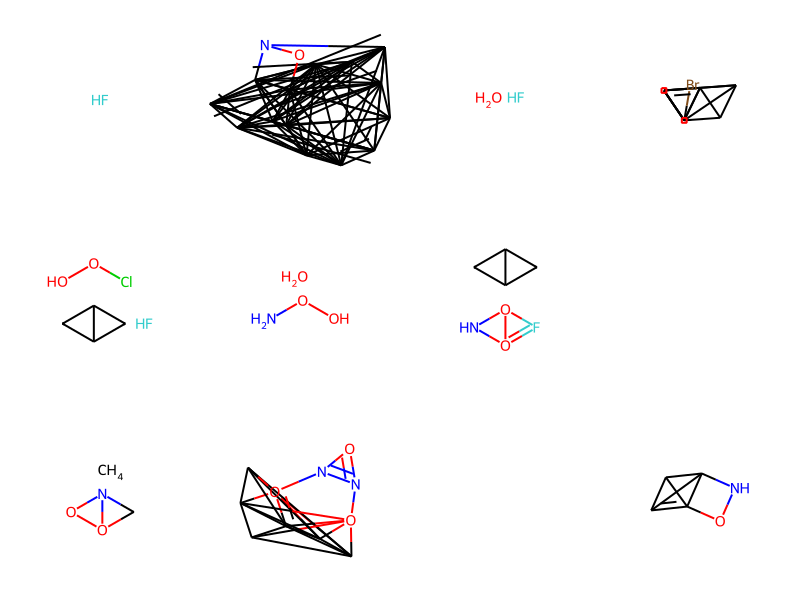

In [14]:
Chem.Draw.MolsToGridImage(
    np.random.choice(sampled_mols, 12, replace=False), molsPerRow=4
)

In [46]:
fully_connected = 0
valid = 0
valid_mols = []
fc_val = 0

for mol in sampled_mols:
    if "." not in Chem.MolToSmiles(mol):
        fully_connected += 1
    try:
        fix_nitro_charges(mol)
        valid += 1
    except:
        pass

    try:
        mol_val = fix_nitro_charges(mol)
        if "." not in Chem.MolToSmiles(mol_val):
            valid_mols.append(mol_val)
            fc_val += 1
    except:
        pass

fc_ratio = fully_connected / n_samples
valid_ratio = valid / n_samples
fc_val_ratio = fc_val / n_samples

print(f"Ratio of fully connected graphs: {fc_ratio*100} %")
print(f"Ratio of chemically valid molecules: {valid_ratio*100} %")
print(f"Ratio of fully connected, valid molecules: {fc_val_ratio*100} % ")

Ratio of fully connected graphs: 25.8 %
Ratio of chemically valid molecules: 72.0 %
Ratio of fully connected, valid molecules: 16.400000000000002 % 


[10:01:41] Explicit valence for atom # 4 C, 6, is greater than permitted
[10:01:41] Explicit valence for atom # 4 C, 6, is greater than permitted
[10:01:41] Explicit valence for atom # 1 C, 7, is greater than permitted
[10:01:41] Explicit valence for atom # 1 C, 7, is greater than permitted
[10:01:41] Explicit valence for atom # 3 C, 7, is greater than permitted
[10:01:41] Explicit valence for atom # 3 C, 7, is greater than permitted
[10:01:41] Explicit valence for atom # 6 C, 5, is greater than permitted
[10:01:41] Explicit valence for atom # 6 C, 5, is greater than permitted
[10:01:41] Explicit valence for atom # 5 C, 5, is greater than permitted
[10:01:41] Explicit valence for atom # 5 C, 5, is greater than permitted
[10:01:41] Explicit valence for atom # 2 C, 5, is greater than permitted
[10:01:41] Explicit valence for atom # 2 C, 5, is greater than permitted
[10:01:41] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:01:41] Explicit valence for atom # 1 C, 6, is g

## 4.2 HIV Molecule Data

### 4.2.1 DeFoG

In [25]:

base_dist = MarginalGraphBase(hiv_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)
n_atom_tokens, n_bond_tokens = (
    hiv_dataset.n_atom_tokens, hiv_dataset.n_bond_tokens)
node_hidden_size, edge_hidden_size = 64, 64
embedding_dim = 8
n_classes = 2
n_update = 4
denoiser = GNNDenoiserCrossAttended(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    embedding_dim, n_layers=n_update, message_passing="gineconv",
    loader=hiv_loader, ca_heads=4,
    conditioning_args=[
        ("cont_sine_pe", {"embedding_dim": embedding_dim}),
        ("class", {"embedding_dim": embedding_dim, "n_classes": 10}),
        ("scalar_fourier", {"embedding_dim": embedding_dim}),
        ("scalar_fourier", {"embedding_dim": embedding_dim}),
        ("scalar_fourier", {"embedding_dim": embedding_dim})
    ]
).to(DEVICE)
sampler = CTMCSampler(
    base_dist, LinearDiscreteRateMatrix(
        base_dist, n_atom_tokens, n_bond_tokens).to(DEVICE), n_atom_tokens,
    n_bond_tokens, hiv_dataset.max_capacity, device=DEVICE,
    bond_types=hiv_dataset.bond_token_names,
)
model = DeFoG(
    base_dist, noiser, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    hiv_dataset.max_capacity
).to(DEVICE)

lambda_ = 4.0
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()
epochs = 100

total_steps = len(hiv_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for batch in hiv_loader:
        optimizer.zero_grad()

        node_weights = torch.ones(batch.x.size(-1), dtype=torch.float)
        node_weights[-1] = 0.4
        edge_weights = torch.ones(batch.edge_attr.size(-1), dtype=torch.float)
        edge_weights[hiv_dataset.bond_token_names.index("triple")] = 0.45
        edge_weights[hiv_dataset.bond_token_names.index("no_bond")] = 0.8
        for i, name in enumerate(hiv_dataset.bond_token_names):
            if name.startswith("bond_"):
                edge_weights[i] = 0.35

        loss = model(
            batch.to(DEVICE), edge_loss_weight=lambda_,
            node_weights=node_weights,
            edge_weights=edge_weights,
        )

        loss.backward()
        optimizer.step()

        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

progress_bar.close()
torch.save(
    model.state_dict(),
    MODEL_DIR / f"hiv_defog_conditional_{epochs}_n_epochs.pt"
)


Training: 100%|██████████| 16100/16100 [1:43:15<00:00,  2.60it/s, epoch=100/100, loss=⠀      0.8786]


In [26]:
progress_bar.reset()

In [31]:

base_dist = MarginalGraphBase(hiv_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)
n_atom_tokens, n_bond_tokens = (
    hiv_dataset.n_atom_tokens, hiv_dataset.n_bond_tokens)
node_hidden_size, edge_hidden_size = 64, 64
embedding_dim = 8
n_classes = 2
n_update = 4
denoiser = GNNDenoiserCrossAttended(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    embedding_dim, n_layers=n_update, message_passing="gineconv",
    loader=hiv_loader, ca_heads=4,
    conditioning_args=[
        ("cont_sine_pe", {"embedding_dim": embedding_dim}),
        ("class", {"embedding_dim": embedding_dim, "n_classes": 10}),
        ("scalar_fourier", {"embedding_dim": embedding_dim}),
        ("scalar_fourier", {"embedding_dim": embedding_dim}),
        ("scalar_fourier", {"embedding_dim": embedding_dim})
    ]
).to(DEVICE)
sampler = CTMCSampler(
    base_dist, LinearDiscreteRateMatrix(
        base_dist, n_atom_tokens, n_bond_tokens).to(DEVICE), n_atom_tokens,
    n_bond_tokens, hiv_dataset.max_capacity, device=DEVICE,
    bond_types=hiv_dataset.bond_token_names,
)
model = DeFoG(
    base_dist, noiser, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    hiv_dataset.max_capacity
).to(DEVICE)

epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"hiv_defog_conditional_{epochs}_n_epochs.pt",
    map_location=torch.device(DEVICE)
))

with torch.inference_mode():
    model.eval()
    n_samples = 100
    n_steps = 100
    y = torch.cat((
        torch.ones((n_samples//2,), dtype=torch.long),
        torch.zeros((n_samples//2,), dtype=torch.long),
    )).to(DEVICE)

    target_n_atoms = 50
    target_n_heteroatoms = 10
    target_n_rings = 3
    sample_max_n_nodes = hiv_dataset.capacity_for_n_atoms(target_n_atoms)
    conditioning = hiv_dataset.sample_conditioning(
        target_n_atoms, target_n_heteroatoms, target_n_rings,
        repeat=n_samples, device=DEVICE,
    )

    batch = model.sample(
        (n_samples,), y=y, conditioning=conditioning, n_steps=n_steps,
        no_atom_bias=-2.3, bond_order_bias=(-1.0, -2.0, 0.0),
        exit_cap=0.6, temp_scales=(0.5, 1.0),
        max_n_nodes=sample_max_n_nodes,
    )


/home/alzub/tmp/ipykernel_1393272/4226597486.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


In [32]:

sampled_mols = batch_to_mols(
    batch, hiv_dataset.atom_vocab, hiv_dataset.bond_vocab,
    sample_max_n_nodes,
)


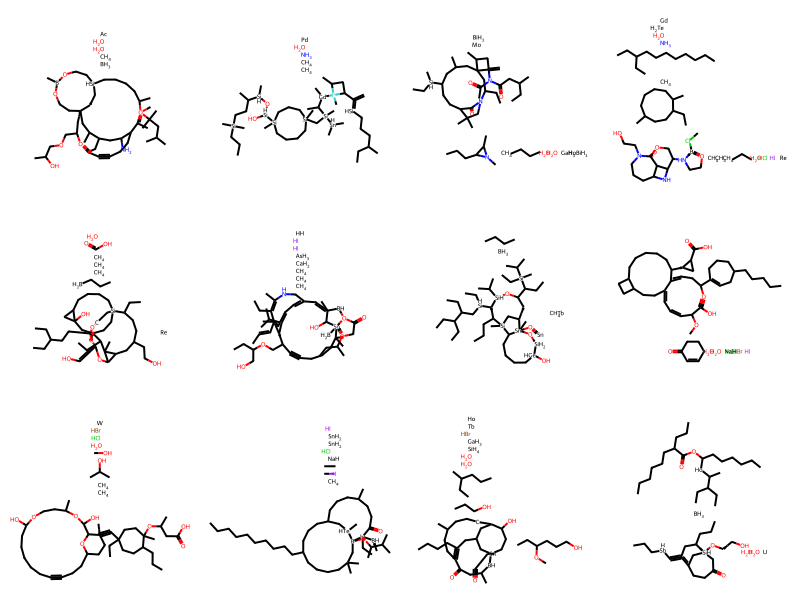

In [33]:
Chem.Draw.MolsToGridImage(
    np.random.choice(sampled_mols, 12, replace=False), molsPerRow=4
)

In [34]:
fully_connected = 0
valid = 0
valid_mols = []
fc_val = 0
fc_val_size = 0

for mol in sampled_mols:
    smiles = Chem.MolToSmiles(mol)
    if "." not in smiles:
        fully_connected += 1
    try:
        fix_nitro_charges(mol)
        valid += 1
    except:
        pass

    try:
        mol_val = fix_nitro_charges(mol)
        if "." not in smiles:
            fc_val_size += mol_val.GetNumAtoms(onlyExplicit=True)
            valid_mols.append(mol_val)
            fc_val += 1
    except:
        pass

fc_ratio = fully_connected / n_samples
valid_ratio = valid / n_samples
fc_val_ratio = fc_val / n_samples
fc_val_size = fc_val_size / fc_val

print(f"Ratio of fully connected graphs: {fc_ratio*100} %")
print(f"Ratio of chemically valid molecules: {valid_ratio*100} %")
print(f"Ratio of fully connected, valid molecules: {fc_val_ratio*100} % ")
print(f"Avg. Size fully connected, valid molecules: {fc_val_size} atoms")

[23:09:02] Explicit valence for atom # 30 N, 4, is greater than permitted
[23:09:02] Explicit valence for atom # 30 N, 4, is greater than permitted
[23:09:02] Explicit valence for atom # 30 Cl, 2, is greater than permitted
[23:09:02] Explicit valence for atom # 30 Cl, 2, is greater than permitted
[23:09:02] Explicit valence for atom # 36 O, 5, is greater than permitted
[23:09:02] Explicit valence for atom # 36 O, 5, is greater than permitted
[23:09:02] Explicit valence for atom # 45 O, 3, is greater than permitted
[23:09:02] Explicit valence for atom # 45 O, 3, is greater than permitted
[23:09:02] Explicit valence for atom # 13 N, 4, is greater than permitted
[23:09:02] Explicit valence for atom # 13 N, 4, is greater than permitted
[23:09:02] Explicit valence for atom # 24 C, 6, is greater than permitted
[23:09:02] Explicit valence for atom # 24 C, 6, is greater than permitted
[23:09:02] Explicit valence for atom # 3 O, 4, is greater than permitted
[23:09:02] Explicit valence for atom 

ZeroDivisionError: division by zero